In [1]:
# %% [Generalized KT solver – CORRECTED time stepping]
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os
import KT_backgrounds as bg

# ---------- physical parameters ----------
L         = 50.0
t_end     = 62.13
Nx        = 1000
dx        = 2.0 * L / Nx
xc        = np.linspace(-L + 0.5*dx, L - 0.5*dx, Nx)

lam       = 63.525          # constant Λ
USE_RTA   = False           # set True for Λ = 12/n(α,T)

# Choose one pair of functions:
T_func = bg.T_const            # or bg.T_gauss_bump, bg.T_sine, ...
v_func = bg.v_const_boost       # or bg.v_const_boost, bg.v_tanh_shear, ...

# ---------- constitutive functions (T-dependent) ----------
@jit(nopython=True, cache=False)
def n_func(alpha, T):
    T3 = T**3
    return (T3 / 3.0) * alpha + (T3 / 27.0) * alpha**3

@jit(nopython=True, cache=False)
def dn_dalpha_func(alpha, T):
    T3 = T**3
    return T3 / 3.0 + (T3 / 9.0) * alpha**2

@jit(nopython=True, cache=False)
def sigma_func(alpha, T):
    return (15.0 * T / (4.0 * np.pi)) * (1.0/27.0 + alpha**2 / (243.0 * np.pi**2))

@jit(nopython=True, cache=False)
def sigmaT_func(alpha, T):
    return sigma_func(alpha, T) * T

@jit(nopython=True, cache=False)
def lambda_func(alpha, T):
    if USE_RTA:
        return 12.0 / n_func(alpha, T)
    else:
        return lam * np.ones_like(alpha)

@jit(nopython=True, cache=False)
def alpha_from_n_func(n, T):
    T3 = T**3
    a = T3 / 3.0
    b = T3 / 27.0
    p = a / b
    q = -n / b
    delta = (q / 2.0)**2 + (p / 3.0)**3
    sqrt_delta = np.sqrt(delta)
    t1 = -q/2.0 + sqrt_delta
    t2 = -q/2.0 - sqrt_delta
    u = np.sign(t1) * np.power(np.abs(t1), 1.0/3.0)
    v = np.sign(t2) * np.power(np.abs(t2), 1.0/3.0)
    return u + v

@jit(nopython=True, cache=False)
def gamma_func(v):
    return 1.0 / np.sqrt(1.0 - v**2)

# ---------- helper: periodic shift ----------
@jit(nopython=True, cache=False)
def roll1d(arr, shift):
    n = arr.size
    s = shift % n
    out = np.empty_like(arr)
    if s == 0:
        out[:] = arr
    else:
        out[:s] = arr[-s:]
        out[s:] = arr[:-s]
    return out

# ---------- primitive recovery (Newton with fallback) ----------
@jit(nopython=True, cache=False)
def cons_to_prim(U1, U2, v, T, lam_local):
    gam = 1.0 / np.sqrt(1.0 - v**2)
    T3 = T**3
    n_guess = U1 / gam
    alpha = 3.0 * n_guess / (T3 + 1e-30)
    for _ in range(30):
        n_val = n_func(alpha, T)
        dn = dn_dalpha_func(alpha, T)
        q_val = (U2 / gam - v * alpha) / lam_local
        f1 = gam * (n_val + v * q_val) - U1
        f2 = gam * (lam_local * q_val + v * alpha) - U2
        df1_dalpha = gam * (dn - v**2 / lam_local)
        df1_dq    = gam * v
        df2_dalpha = gam * v
        df2_dq    = gam * lam_local
        det = df1_dalpha * df2_dq - df1_dq * df2_dalpha
        if abs(det) < 1e-12:
            break
        dalpha = -(f1 * df2_dq - df1_dq * f2) / det
        dq     = -(df1_dalpha * f2 - f1 * df2_dalpha) / det
        alpha += dalpha
        q_val += dq
        if abs(dalpha) < 1e-10 and abs(dq) < 1e-10:
            break
    if alpha < -100.0: alpha = -100.0
    if alpha > 100.0: alpha = 100.0
    return alpha, q_val

# ---------- initial conditions ----------
def make_IC():
    t0 = 0.0
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc / L)**2) + r) * 1e-2
    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc / L)**2) + g) * 1e-6
    T0 = T_func(t0, xc)
    alpha_init = np.array([alpha_from_n_func(ni, Ti) for ni, Ti in zip(n_init, T0)])
    v0 = v_func(t0, xc)
    gam = gamma_func(v0)
    U1_init = gam * (n_init + v0 * q_init)
    U2_init = gam * (lam * q_init + v0 * alpha_init)
    return n_init, q_init, alpha_init, U1_init, U2_init

# ---------- numerical flux (Kurganov–Tadmor) ----------
@jit(nopython=True, cache=False)
def numerical_flux(U1, U2, v_face, T_face):
    dU1  = (roll1d(U1, -1) - U1) / dx
    dU1p = (U1 - roll1d(U1, 1)) / dx
    sU1 = np.zeros_like(U1)
    for i in range(Nx):
        if dU1[i] * dU1p[i] > 0.0:
            sU1[i] = min(abs(dU1[i]), abs(dU1p[i])) * np.sign(dU1[i])

    dU2  = (roll1d(U2, -1) - U2) / dx
    dU2p = (U2 - roll1d(U2, 1)) / dx
    sU2 = np.zeros_like(U2)
    for i in range(Nx):
        if dU2[i] * dU2p[i] > 0.0:
            sU2[i] = min(abs(dU2[i]), abs(dU2p[i])) * np.sign(dU2[i])

    U1_minus = U1 + 0.5 * dx * sU1
    U2_minus = U2 + 0.5 * dx * sU2
    U1_plus  = roll1d(U1, -1) - 0.5 * dx * roll1d(sU1, -1)
    U2_plus  = roll1d(U2, -1) - 0.5 * dx * roll1d(sU2, -1)

    H = np.zeros((2, Nx))
    for i in range(Nx):
        vf = v_face[i]
        Tf = T_face[i]
        am, qm = cons_to_prim(U1_minus[i], U2_minus[i], vf, Tf, lam)
        ap, qp = cons_to_prim(U1_plus[i], U2_plus[i], vf, Tf, lam)

        Lm = 12.0 / n_func(am, Tf) if USE_RTA else lam
        Lp = 12.0 / n_func(ap, Tf) if USE_RTA else lam

        gam = 1.0 / np.sqrt(1.0 - vf**2)
        F1m = gam * (vf * n_func(am, Tf) + qm)
        F2m = gam * (vf * Lm * qm + am)
        F1p = gam * (vf * n_func(ap, Tf) + qp)
        F2p = gam * (vf * Lp * qp + ap)

        dnm = dn_dalpha_func(am, Tf)
        dnp = dn_dalpha_func(ap, Tf)
        cs_m = np.sqrt(1.0 / (dnm * Lm + 1e-30))
        cs_p = np.sqrt(1.0 / (dnp * Lp + 1e-30))
        a_max = abs(vf) + max(cs_m, cs_p)

        H[0,i] = 0.5*(F1m + F1p) - 0.5*a_max*(U1_plus[i] - U1_minus[i])
        H[1,i] = 0.5*(F2m + F2p) - 0.5*a_max*(U2_plus[i] - U2_minus[i])
    return H

# ---------- RHS ----------
@jit(nopython=True, cache=False)
def rhs(U1, U2, t, xc):
    T_arr = T_func(t, xc)
    v_arr = v_func(t, xc)
    H = numerical_flux(U1, U2, v_arr, T_arr)
    dU1 = -(H[0] - roll1d(H[0], 1)) / dx
    dU2 = -(H[1] - roll1d(H[1], 1)) / dx

    alpha_c = np.zeros(Nx)
    q_c = np.zeros(Nx)
    for i in range(Nx):
        ai, qi = cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
        alpha_c[i] = ai
        q_c[i] = qi
    dU2 -= q_c / sigmaT_func(alpha_c, T_arr)
    return dU1, dU2

# ---------- time stepping ----------
@jit(nopython=True, cache=False)
def step_RK2(U1, U2, t, xc, dt):
    dU1, dU2 = rhs(U1, U2, t, xc)
    U1_1 = U1 + dt * dU1
    U2_1 = U2 + dt * dU2
    dU1_2, dU2_2 = rhs(U1_1, U2_1, t+dt, xc)
    return (U1 + 0.5*dt*(dU1 + dU1_2),
            U2 + 0.5*dt*(dU2 + dU2_2))

# ---------- main simulation (with exact snapshot times) ----------
n_init, q_init, alpha_init, U1, U2 = make_IC()

save_times = np.linspace(0, t_end, 201)
n_store = np.zeros((len(save_times), Nx))
q_store = np.zeros((len(save_times), Nx))
alpha_store = np.zeros((len(save_times), Nx))
n_store[0] = n_init; q_store[0] = q_init; alpha_store[0] = alpha_init
save_idx = 0

t = 0.0
tol = 1e-10
while t < t_end:
    v_arr = v_func(t, xc)
    T_arr = T_func(t, xc)

    # CFL using analytic characteristic speed
    alpha_c = np.zeros(Nx)
    for i in range(Nx):
        ai, _ = cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
        alpha_c[i] = ai
    dn_arr = dn_dalpha_func(alpha_c, T_arr)
    cs = np.sqrt(1.0 / (dn_arr * lam + 1e-30))
    a_max = np.max(np.abs(v_arr) + cs)
    if a_max < 1e-12:
        a_max = 1e-12
    dt_cfl = 0.125 * dx / a_max

    # --- exact time control for snapshot alignment ---
    target_time = save_times[save_idx + 1]
    dt = min(dt_cfl, target_time - t)

    U1, U2 = step_RK2(U1, U2, t, xc, dt)
    t += dt

    while save_idx+1 < len(save_times) and t >= save_times[save_idx+1] - tol:
        save_idx += 1
        v_s = v_func(t, xc); T_s = T_func(t, xc)
        for i in range(Nx):
            ai, qi = cons_to_prim(U1[i], U2[i], v_s[i], T_s[i], lam)
            alpha_store[save_idx,i] = ai
            q_store[save_idx,i] = qi
            n_store[save_idx,i] = n_func(ai, T_s[i])

print(f"Simulation finished after {save_idx+1} snapshots.")

# ---------- save snapshots ----------
run_dir = "./KT_DivType_general"
os.makedirs(run_dir, exist_ok=True)
np.savez(os.path.join(run_dir, "snapshots.npz"),
         t=save_times, x=xc,
         n=n_store, q=q_store, alpha=alpha_store)
print(f"Saved to {run_dir}/snapshots.npz")

# %% [KT plots & figure saving]
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 300,
    'savefig.dpi': 300
})

def custom_colormap():
    cmap = plt.get_cmap("Greys_r", 256)
    vals = np.interp(np.linspace(0, 1, 256),
                     [0.0, 1/3, 2/3, 1.0],
                     [0.0, 0.35, 0.59, 0.81])
    return ListedColormap(cmap(vals))

def save_kt_field(field, x, t, ylabel, filename, cmap_heat='gist_heat'):
    Nt = len(t)
    times = np.linspace(0, Nt-1, 4, dtype=int)
    cmap = custom_colormap()
    fig = plt.figure(figsize=(9, 7), constrained_layout=True)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.48, 0.52], hspace=0.18)
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],
                                              width_ratios=[1.15, 0.32], wspace=0.05)
    ax_snap = fig.add_subplot(gs_top[0, 0])
    ax_leg  = fig.add_subplot(gs_top[0, 1])
    gs_bot = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1],
                                              width_ratios=[1.05, 0.06], wspace=0.05)
    ax_heat = fig.add_subplot(gs_bot[0, 0])
    cax     = fig.add_subplot(gs_bot[0, 1])

    for i, ti in enumerate(times):
        ax_snap.plot(x, field[ti],
                     color=cmap(i/(len(times)-1)),
                     ls='--', lw=2.5,
                     label=fr'$t={t[ti]:.2f}\,[\mathrm{{GeV^{{-1}}}}]$')
    ax_snap.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_snap.set_ylabel(ylabel)
    ax_leg.axis('off')
    h, l = ax_snap.get_legend_handles_labels()
    ax_leg.legend(h, l, loc='center', frameon=False,
                  handlelength=1.2, handletextpad=0.5)

    pcm = ax_heat.pcolormesh(x, t, field, shading='auto', cmap=cmap_heat)
    ax_heat.set_xlabel(r'$x\,{\rm [GeV^{-1}]}$')
    ax_heat.set_ylabel(r'$t\,{\rm [GeV^{-1}]}$')
    cb = fig.colorbar(pcm, cax=cax)
    cb.set_label(ylabel)

    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

save_folder = "./plots/KT/constant"
os.makedirs(save_folder, exist_ok=True)
save_kt_field(n_store, xc, save_times, r'$n\,{\rm [GeV^3]}$',
              os.path.join(save_folder, "field_n.pdf"))
save_kt_field(q_store, xc, save_times, r'$\mathcal{J}$',
              os.path.join(save_folder, "field_q.pdf"))
save_kt_field(alpha_store, xc, save_times, r'$\alpha$',
              os.path.join(save_folder, "field_alpha.pdf"))

print(f"Figures saved in {save_folder}")

Simulation finished after 201 snapshots.
Saved to ./KT_DivType_general/snapshots.npz
Figures saved in ./plots/KT/constant


# Mass conservation

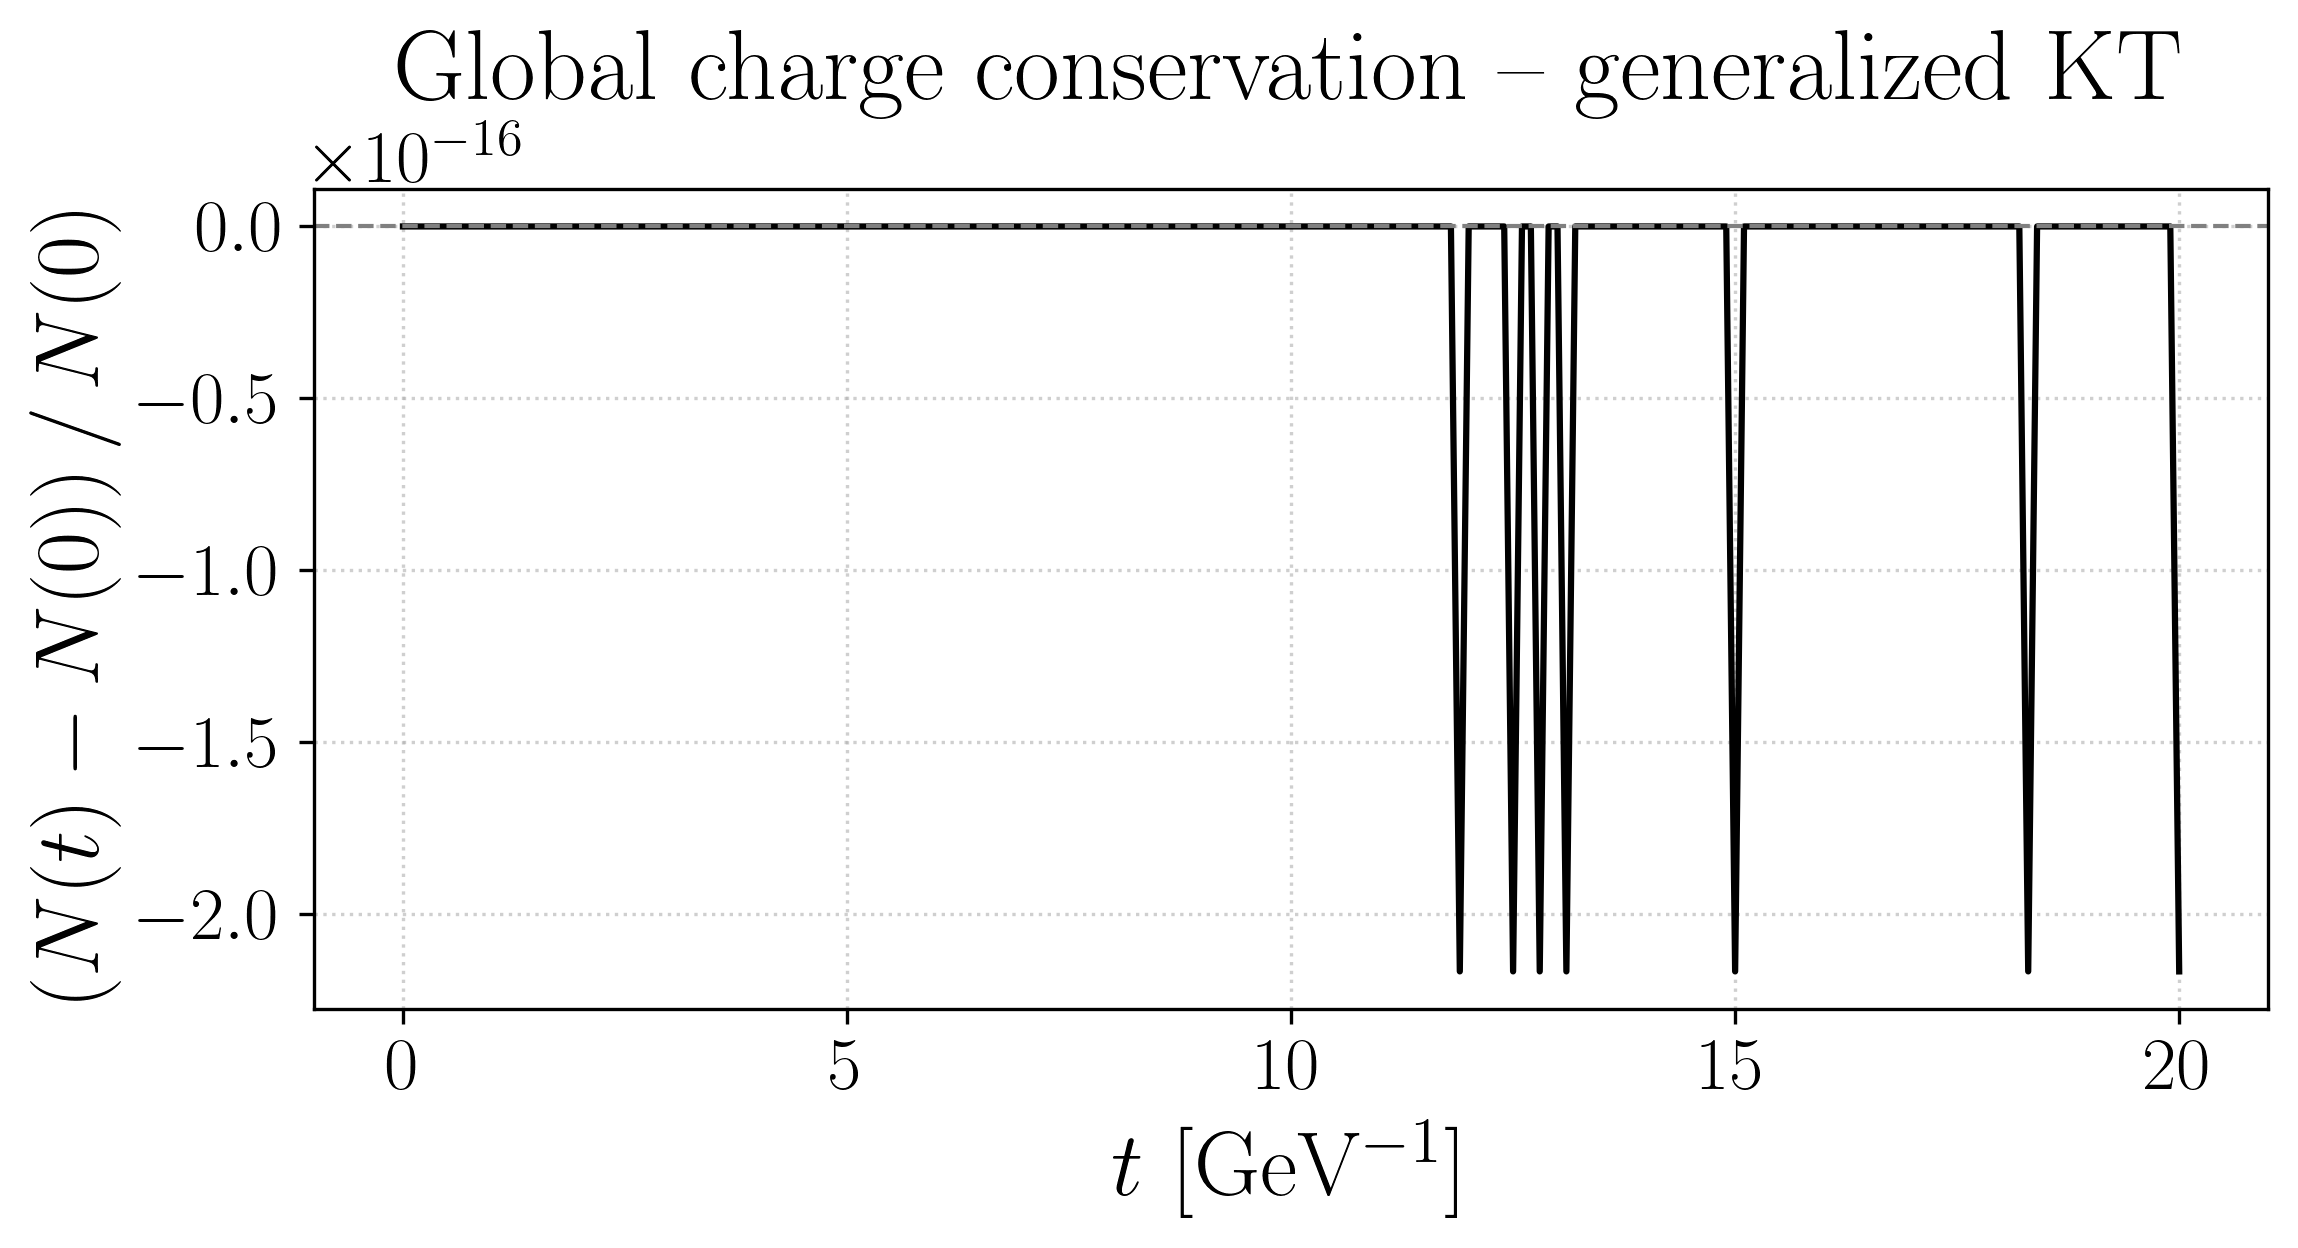

Total charge conserved to a fraction of  2.2e-16


In [7]:
# %% [Mass conservation – generalized KT, high‑quality]
import numpy as np
import matplotlib.pyplot as plt

# ----- load the generalized KT snapshot ---------------------------------------
data = np.load("./KT_DivType_general/snapshots.npz")
t_kt   = data["t"]
x_kt   = data["x"]
n_kt   = data["n"]

# ----- compute total charge over time ----------------------------------------
dx_kt = x_kt[1] - x_kt[0]
N_t = n_kt.sum(axis=1) * dx_kt
N0 = N_t[0]
frac_var = (N_t - N0) / N0

# ----- publication‑quality plot -----------------------------------------------
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
})

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_kt, frac_var, 'k-', lw=1.5)
ax.axhline(0, color='grey', ls='--', lw=1)
ax.set_xlabel(r'$t$ [GeV${}^{-1}$]')
ax.set_ylabel(r'$(N(t)-N(0))\,/\,N(0)$')
ax.set_title('Global charge conservation – generalized KT')
ax.grid(True, which='major', ls=':', alpha=0.6)
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))

plt.tight_layout()
fig.savefig("./plots/KT/mass_conservation.pdf", bbox_inches='tight')
plt.show()

print(f"Total charge conserved to a fraction of  {np.max(np.abs(frac_var)):.1e}")

# Causality analysis and Residuals

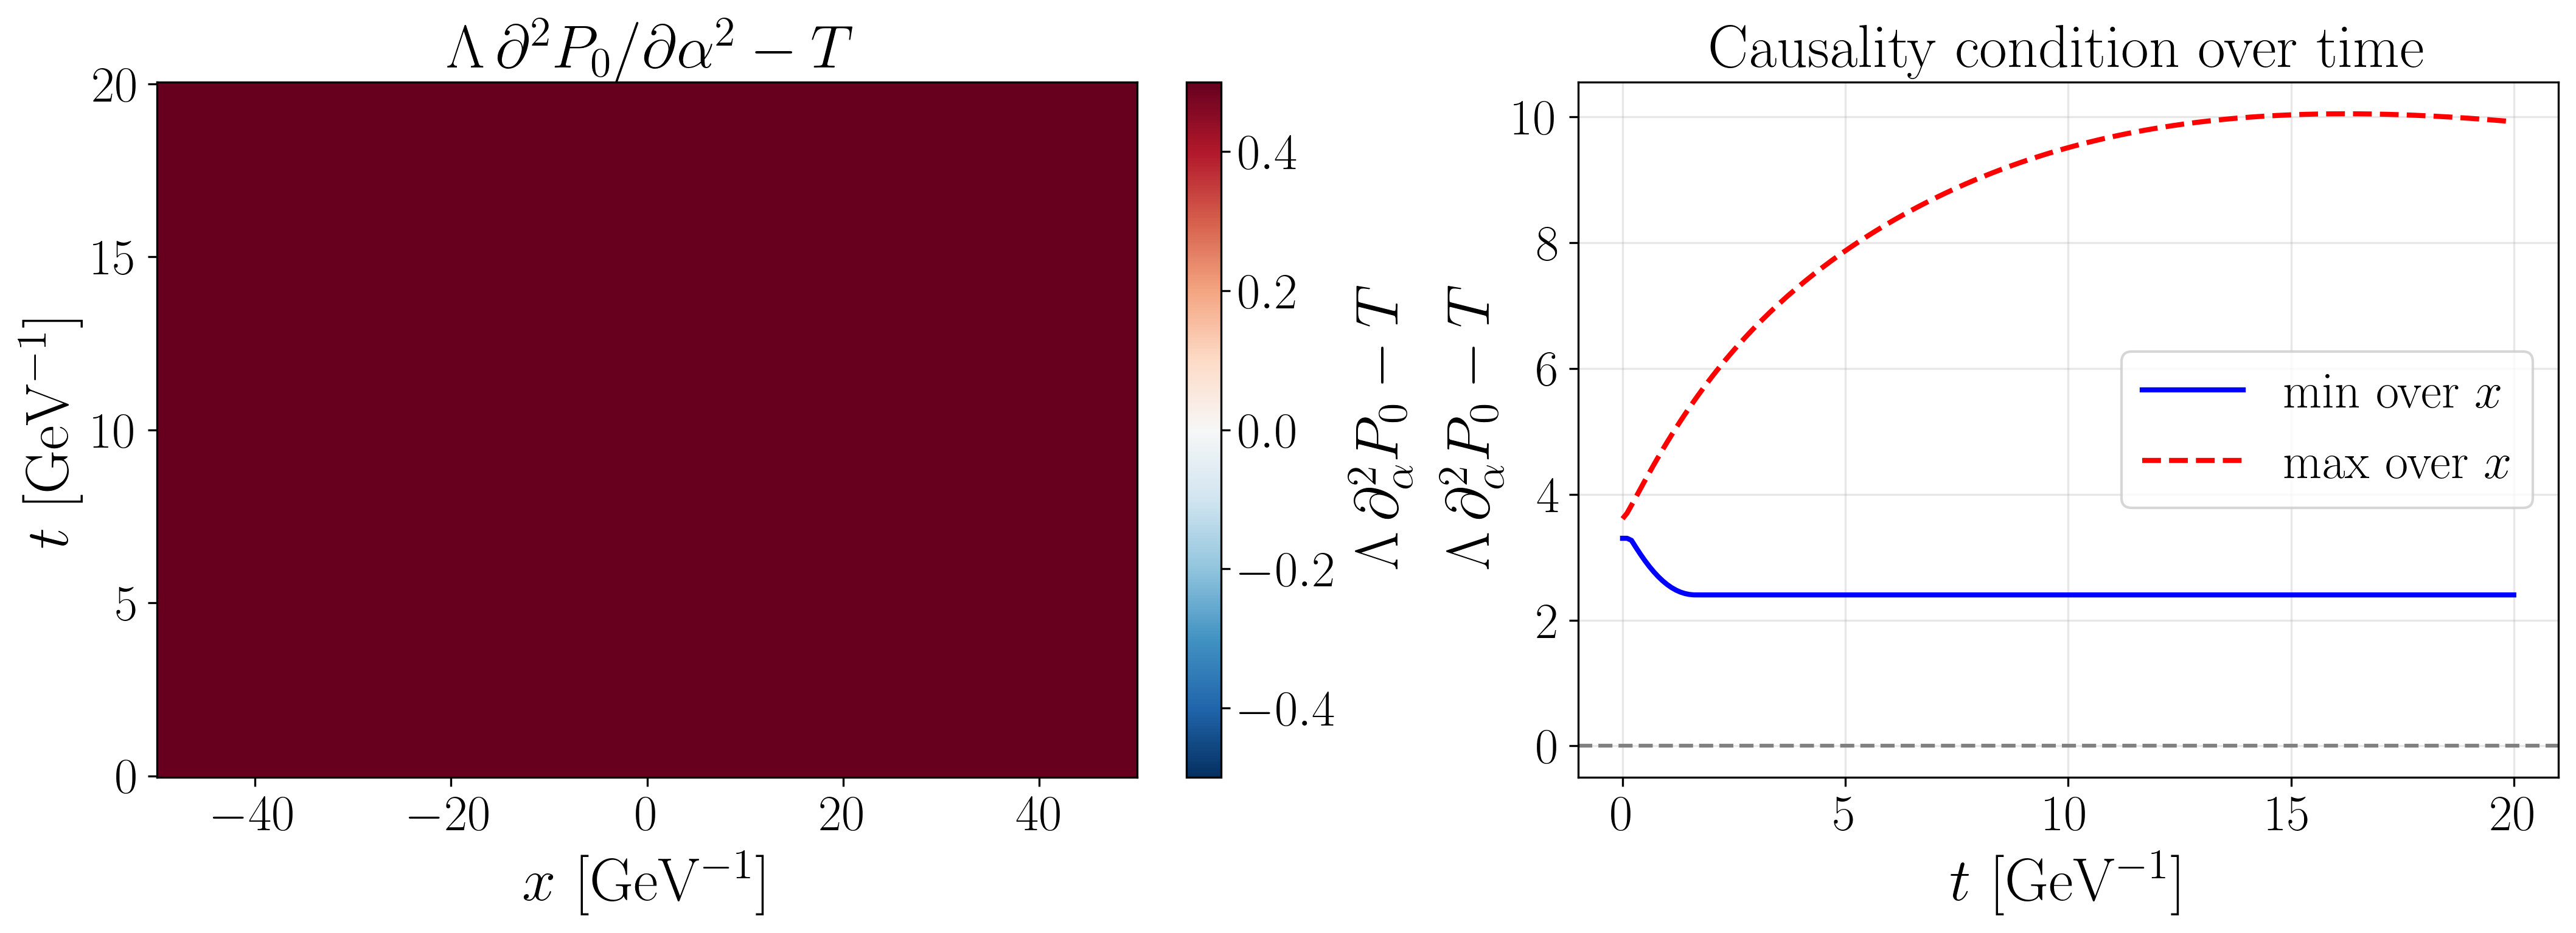

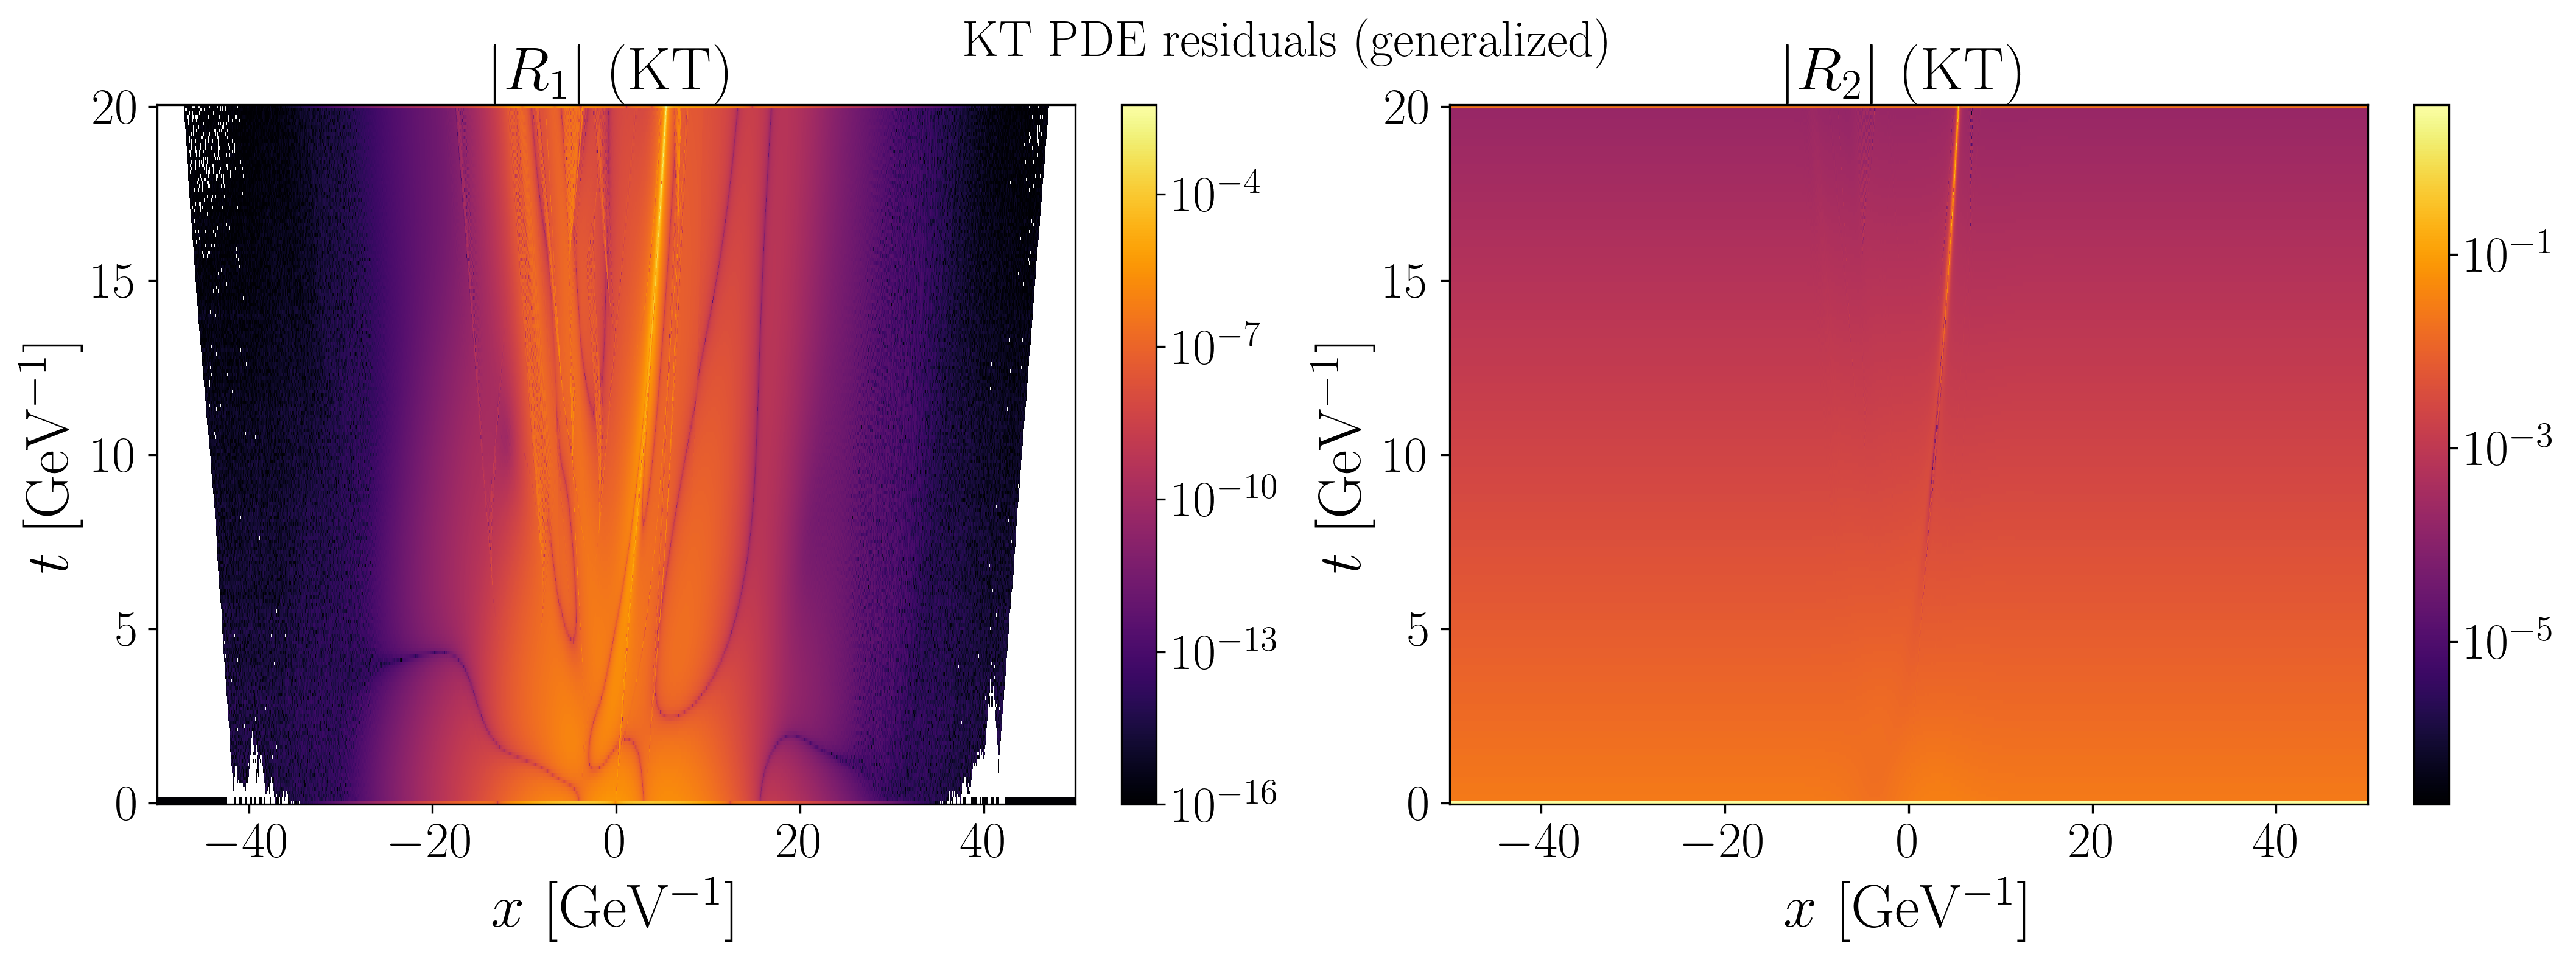

In [7]:
# %% [Causality & PDE residuals – generalized KT]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ── Load generalized KT snapshot (or use in‑memory arrays) ─────────────────
data = np.load("./KT_DivType_general/snapshots.npz")
t_arr = data["t"]
x_arr = data["x"]
n_arr = data["n"]
q_arr = data["q"]
alpha_arr = data["alpha"]

# ── Reconstruct background fields on the same grid ──────────────────────────
# (Use the global T_func and v_func that were used in the simulation)
T_arr = np.array([[T_func(ti, xi) for xi in x_arr] for ti in t_arr])
v_arr = np.array([[v_func(ti, xi) for xi in x_arr] for ti in t_arr])
gamma_arr = 1.0 / np.sqrt(1.0 - v_arr**2)

# ── Causality indicator (local) ─────────────────────────────────────────────
d2P0 = (T_arr**4 / 3.0) + (T_arr**4 / 9.0) * alpha_arr**2
causality = lam * d2P0 - T_arr            # must be ≥ 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Heatmap
im = axes[0].pcolormesh(x_arr, t_arr, causality, shading='auto',
                        cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0].set_xlabel(r'$x$ [GeV${}^{-1}$]')
axes[0].set_ylabel(r'$t$ [GeV${}^{-1}$]')
axes[0].set_title(r'$\Lambda\,\partial^2 P_0/\partial\alpha^2 - T$')
cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label(r'$\Lambda\,\partial_{\alpha}^2 P_0 - T$')

# Time evolution of min and max
min_caus = causality.min(axis=1)
max_caus = causality.max(axis=1)
axes[1].plot(t_arr, min_caus, 'b-', lw=2, label='min over $x$')
axes[1].plot(t_arr, max_caus, 'r--', lw=2, label='max over $x$')
axes[1].axhline(0, color='gray', ls='--')
axes[1].set_xlabel(r'$t$ [GeV${}^{-1}$]')
axes[1].set_ylabel(r'$\Lambda\,\partial_{\alpha}^2 P_0 - T$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Causality condition over time')

plt.savefig("./plots/KT/causality.pdf", bbox_inches='tight')
plt.show()

# ── PDE residuals (generalized conservative form) ────────────────────────────
# Conservative variables and fluxes
U1 = gamma_arr * (n_arr + v_arr * q_arr)
U2 = gamma_arr * (lam * q_arr + v_arr * alpha_arr)      # constant Λ used here
F1 = gamma_arr * (v_arr * n_arr + q_arr)
F2 = gamma_arr * (lam * v_arr * q_arr + alpha_arr)      # F2 = γ( vΛq + α )

# Numerical derivatives
dt = t_arr[1] - t_arr[0]
dx = x_arr[1] - x_arr[0]
U1_t = np.gradient(U1, dt, axis=0)
U2_t = np.gradient(U2, dt, axis=0)
F1_x = np.gradient(F1, dx, axis=1)
F2_x = np.gradient(F2, dx, axis=1)

# Source term for R2
T_loc = T_arr
sigT = sigma_func(alpha_arr, T_loc) * T_loc    # use generalized sigmaT_func
source = q_arr / sigT

R1 = U1_t + F1_x
R2 = U2_t + F2_x + source

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, data, title in zip(axes3,
                           [np.abs(R1), np.abs(R2)],
                           [r'$|R_1|$ (KT)', r'$|R_2|$ (KT)']):
    im = ax.pcolormesh(x_arr, t_arr, data, shading='auto',
                       norm=LogNorm(vmin=max(1e-16, data[data>0].min()),
                                    vmax=data.max()),
                       cmap='inferno')
    ax.set_xlabel(r'$x$ [GeV${}^{-1}$]')
    ax.set_ylabel(r'$t$ [GeV${}^{-1}$]')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle('KT PDE residuals (generalized)', fontsize=20, y=1.02)
plt.savefig("./plots/KT/PDE_residuals.pdf", bbox_inches='tight')
plt.show()

# Convergence test

  Running Nx=4000 ... done in 10.3s
  Running Nx=8000 ... done in 33.9s
  Running Nx=16000 ... done in 122.8s

Wall‑clock times:
  Nx= 4000: 10.34 s
  Nx= 8000: 33.90 s
  Nx=16000: 122.78 s


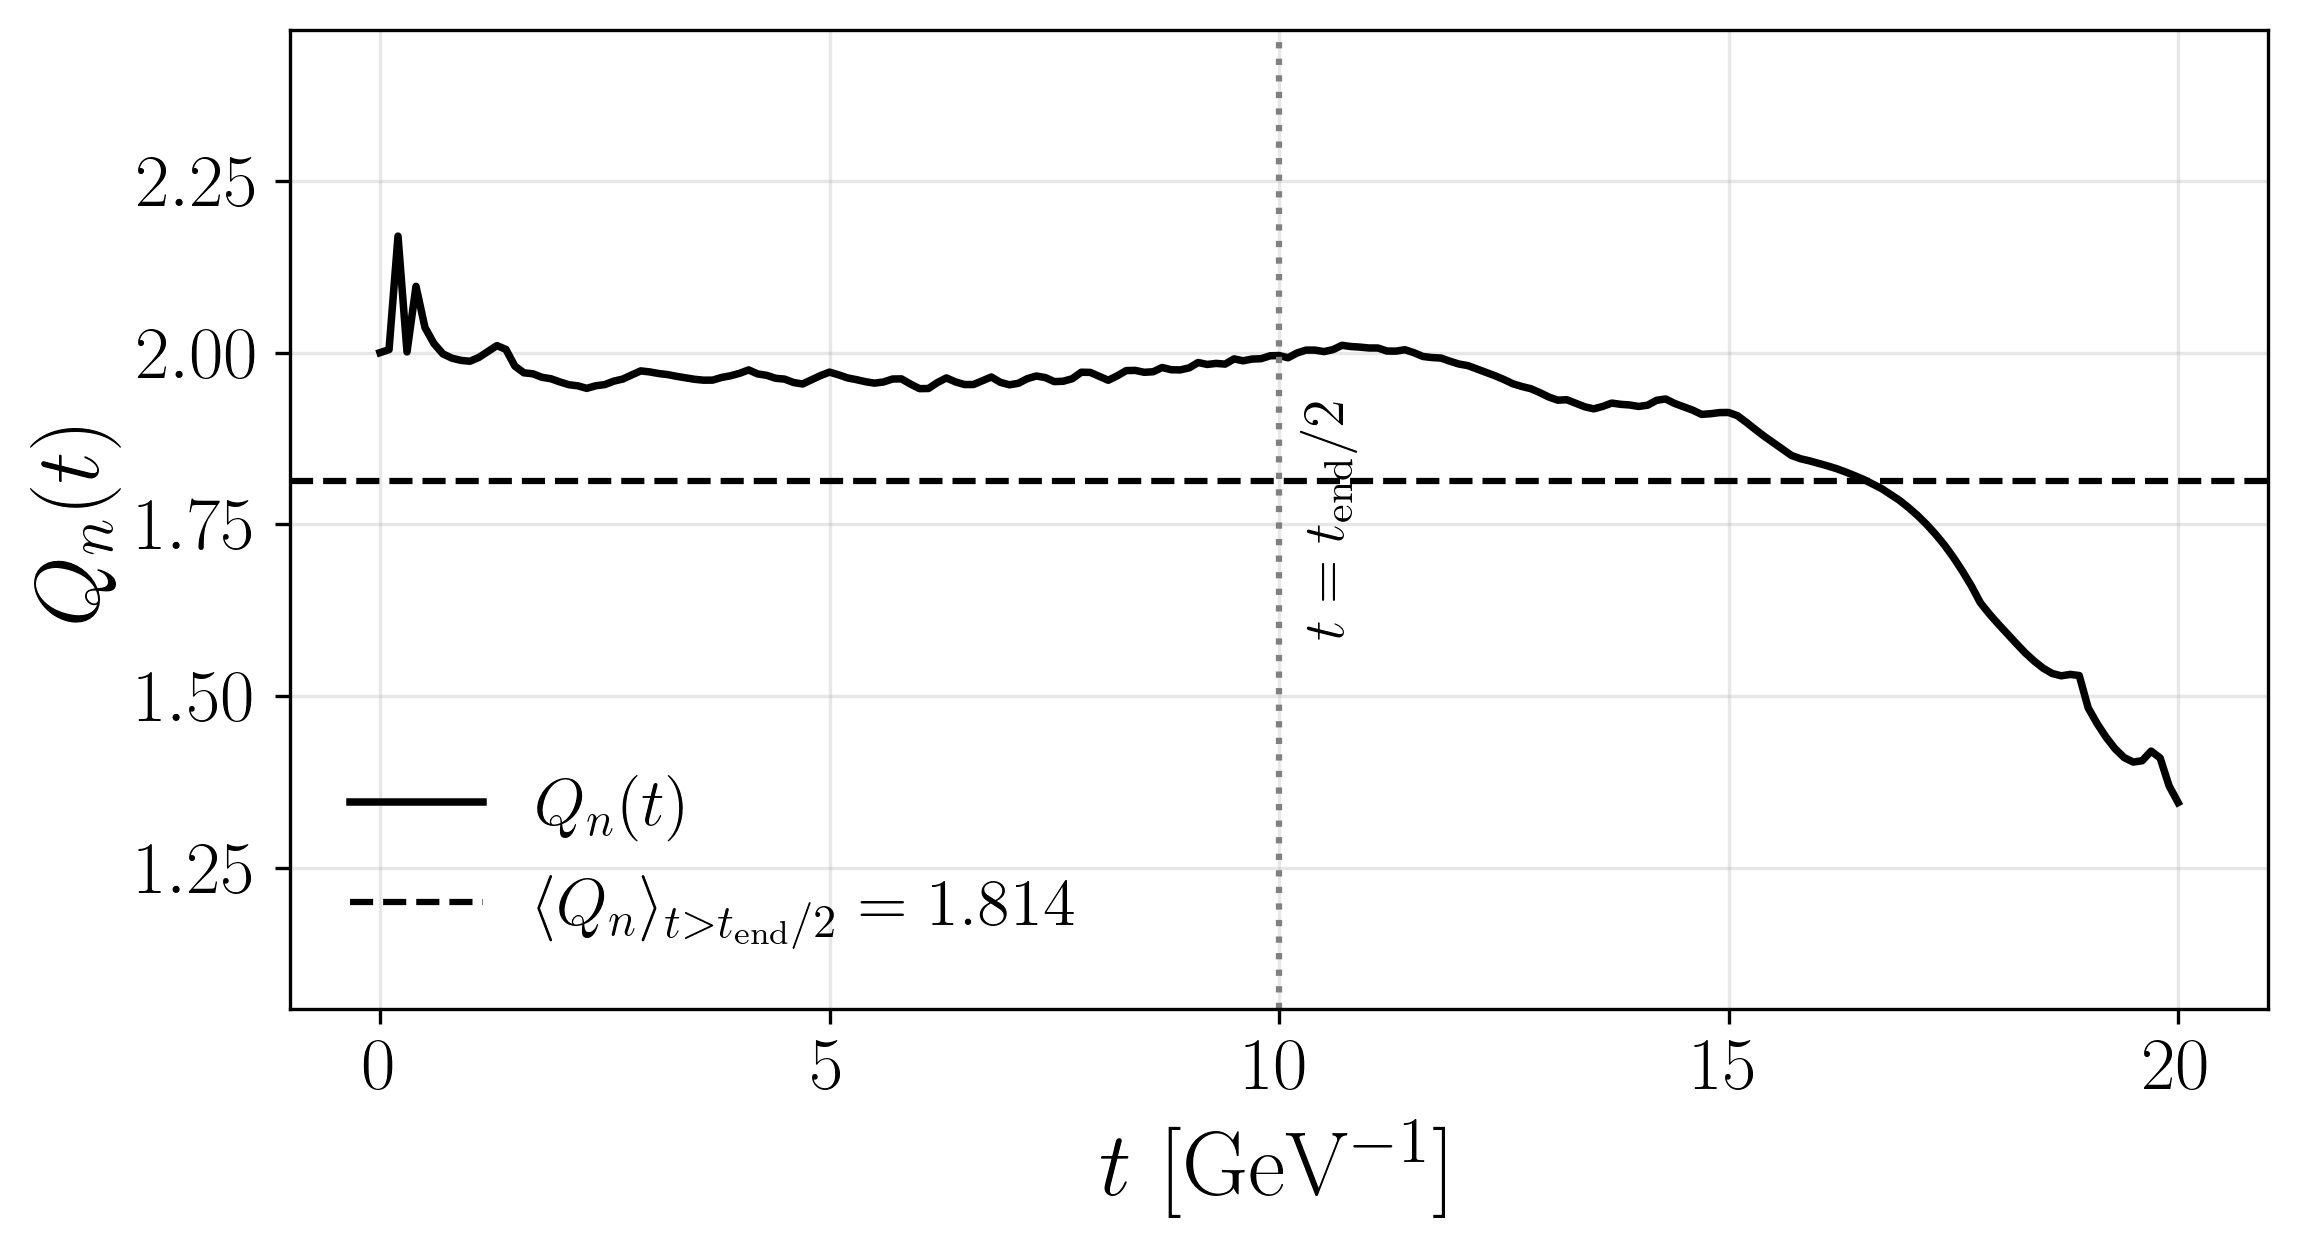

Mean Q_n for t > t_end/2 = 1.814


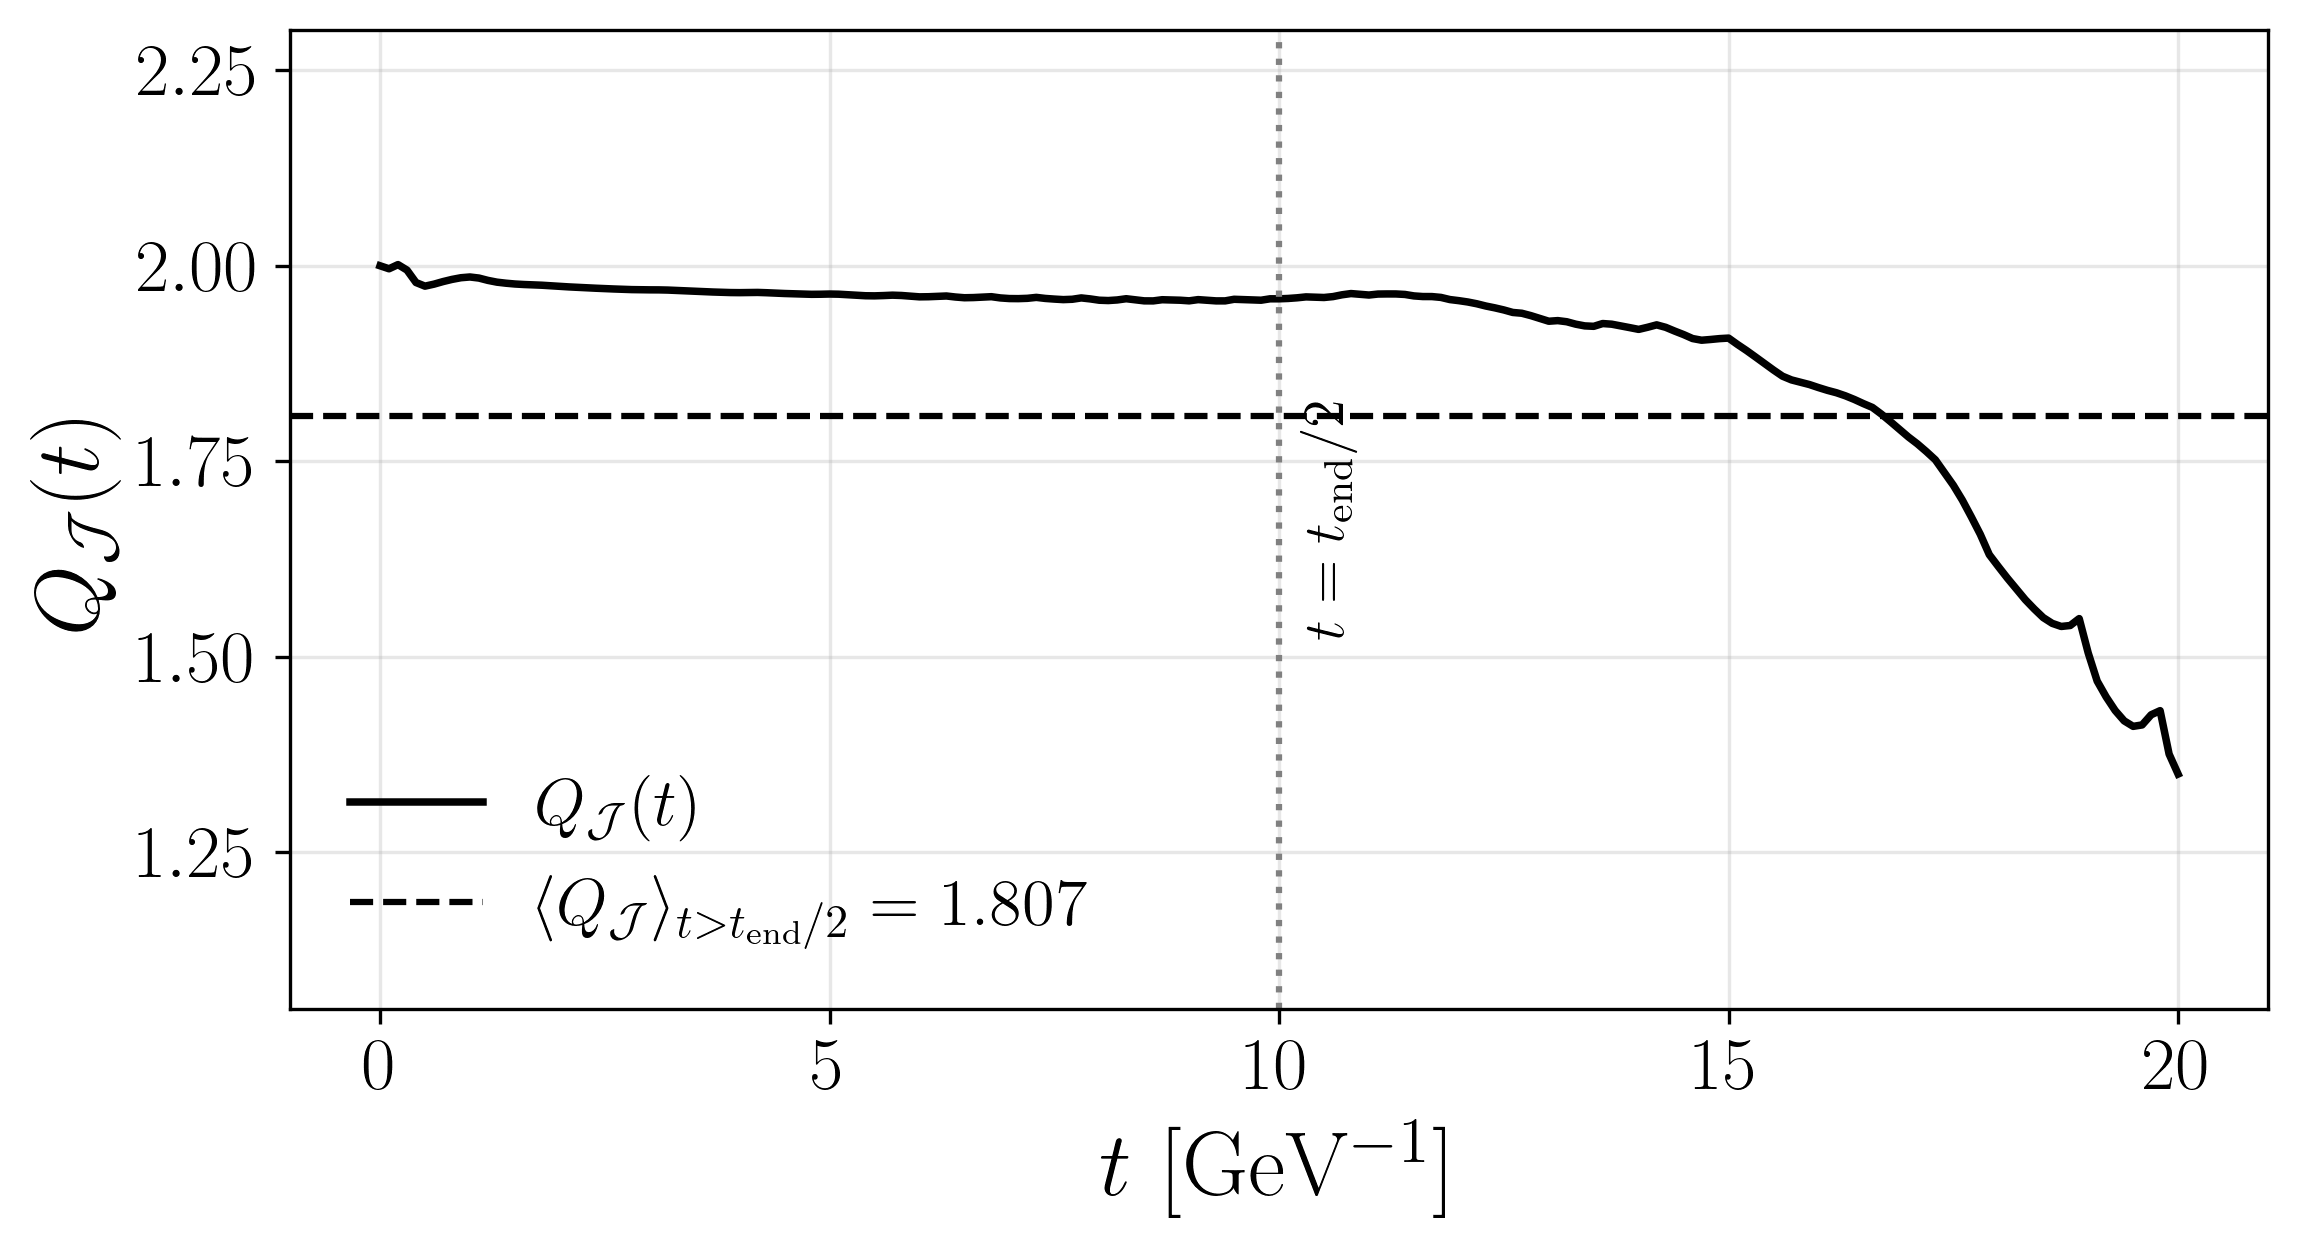

Mean Q_q for t > t_end/2 = 1.807


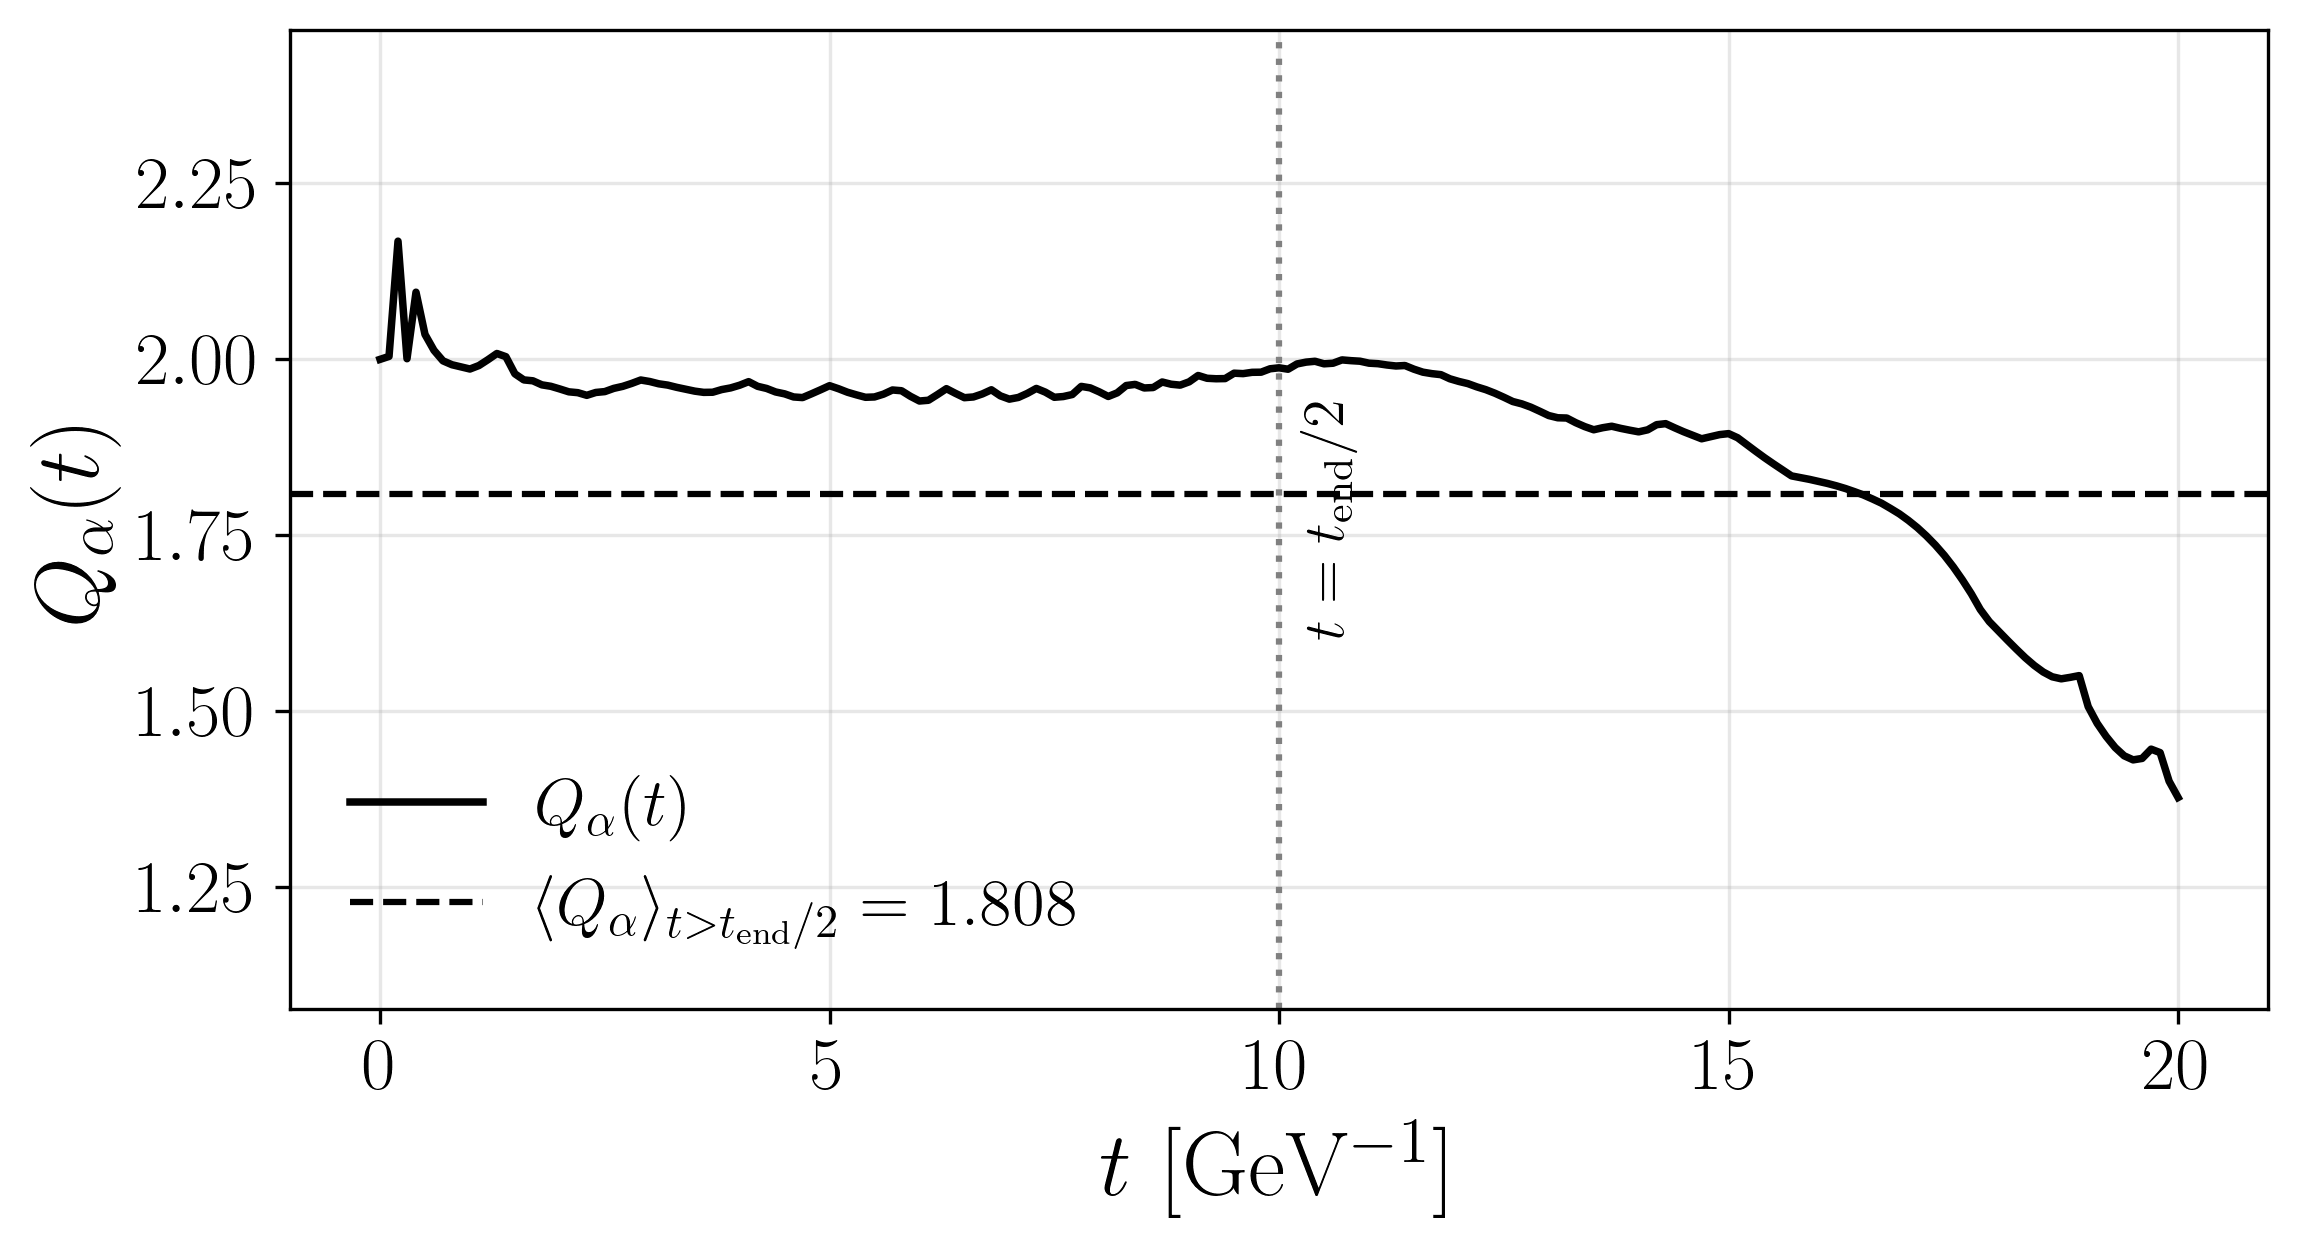

Mean Q_alpha for t > t_end/2 = 1.808

Convergence test completed.


In [5]:
# %% [Convergence test – fully self‑contained second cell]
import time as _time
import numpy as np
from numba import jit
import matplotlib.pyplot as plt
import os

# ── Style (consistent with first cell) ─────────────────────────────────────
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 18,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
})

# ── Resolutions (must be 2:1) ────────────────────────────────────────────
Nx_runs = [4000, 8000, 16000]
save_times_conv = np.linspace(0, t_end, 201)   # identical to first cell

# ── Wrapper: run the generalized KT solver for a given Nx ─────────────────
def run_kt_generalized(Nx_val: int, save_t: np.ndarray) -> dict:
    """Run the KT solver with Nx_val cells and return snapshots at save_t."""
    # ----- local grid -----
    dx_val = 2.0 * L / Nx_val
    xc_val = np.linspace(-L + 0.5 * dx_val, L - 0.5 * dx_val, Nx_val)

    # ----- local JIT functions (capture dx_val, Nx_val, global physics) -----
    @jit(nopython=True, cache=False)
    def _roll1d(arr, shift):
        n = arr.size
        s = shift % n
        out = np.empty_like(arr)
        if s == 0:
            out[:] = arr
        else:
            out[:s] = arr[-s:]
            out[s:] = arr[:-s]
        return out

    @jit(nopython=True, cache=False)
    def _cons_to_prim(U1, U2, v, T, lam_local):
        gam = 1.0 / np.sqrt(1.0 - v**2)
        T3 = T**3
        n_guess = U1 / gam
        alpha = 3.0 * n_guess / (T3 + 1e-30)
        for _ in range(30):
            n_val = n_func(alpha, T)
            dn = dn_dalpha_func(alpha, T)
            q_val = (U2 / gam - v * alpha) / lam_local
            f1 = gam * (n_val + v * q_val) - U1
            f2 = gam * (lam_local * q_val + v * alpha) - U2
            df1_dalpha = gam * (dn - v**2 / lam_local)
            df1_dq    = gam * v
            df2_dalpha = gam * v
            df2_dq    = gam * lam_local
            det = df1_dalpha * df2_dq - df1_dq * df2_dalpha
            if abs(det) < 1e-12:
                break
            dalpha = -(f1 * df2_dq - df1_dq * f2) / det
            dq     = -(df1_dalpha * f2 - f1 * df2_dalpha) / det
            alpha += dalpha
            q_val += dq
            if abs(dalpha) < 1e-10 and abs(dq) < 1e-10:
                break
        if alpha < -100.0: alpha = -100.0
        if alpha > 100.0: alpha = 100.0
        return alpha, q_val

    @jit(nopython=True, cache=False)
    def _numerical_flux(U1, U2, v_face, T_face):
        dU1  = (_roll1d(U1, -1) - U1) / dx_val
        dU1p = (U1 - _roll1d(U1, 1)) / dx_val
        sU1 = np.zeros_like(U1)
        for i in range(Nx_val):
            if dU1[i] * dU1p[i] > 0.0:
                sU1[i] = min(abs(dU1[i]), abs(dU1p[i])) * np.sign(dU1[i])

        dU2  = (_roll1d(U2, -1) - U2) / dx_val
        dU2p = (U2 - _roll1d(U2, 1)) / dx_val
        sU2 = np.zeros_like(U2)
        for i in range(Nx_val):
            if dU2[i] * dU2p[i] > 0.0:
                sU2[i] = min(abs(dU2[i]), abs(dU2p[i])) * np.sign(dU2[i])

        U1_minus = U1 + 0.5 * dx_val * sU1
        U2_minus = U2 + 0.5 * dx_val * sU2
        U1_plus  = _roll1d(U1, -1) - 0.5 * dx_val * _roll1d(sU1, -1)
        U2_plus  = _roll1d(U2, -1) - 0.5 * dx_val * _roll1d(sU2, -1)

        H = np.zeros((2, Nx_val))
        for i in range(Nx_val):
            vf = v_face[i]
            Tf = T_face[i]
            am, qm = _cons_to_prim(U1_minus[i], U2_minus[i], vf, Tf, lam)
            ap, qp = _cons_to_prim(U1_plus[i], U2_plus[i], vf, Tf, lam)

            Lm = 12.0 / n_func(am, Tf) if USE_RTA else lam
            Lp = 12.0 / n_func(ap, Tf) if USE_RTA else lam

            gam = 1.0 / np.sqrt(1.0 - vf**2)
            F1m = gam * (vf * n_func(am, Tf) + qm)
            F2m = gam * (vf * Lm * qm + am)
            F1p = gam * (vf * n_func(ap, Tf) + qp)
            F2p = gam * (vf * Lp * qp + ap)

            dnm = dn_dalpha_func(am, Tf)
            dnp = dn_dalpha_func(ap, Tf)
            cs_m = np.sqrt(1.0 / (dnm * Lm + 1e-30))
            cs_p = np.sqrt(1.0 / (dnp * Lp + 1e-30))
            a_max = abs(vf) + max(cs_m, cs_p)

            H[0,i] = 0.5*(F1m + F1p) - 0.5*a_max*(U1_plus[i] - U1_minus[i])
            H[1,i] = 0.5*(F2m + F2p) - 0.5*a_max*(U2_plus[i] - U2_minus[i])
        return H

    @jit(nopython=True, cache=False)
    def _rhs(U1, U2, t, xc_local):
        T_arr = T_func(t, xc_local)
        v_arr = v_func(t, xc_local)
        H = _numerical_flux(U1, U2, v_arr, T_arr)
        dU1 = -(H[0] - _roll1d(H[0], 1)) / dx_val
        dU2 = -(H[1] - _roll1d(H[1], 1)) / dx_val
        alpha_c = np.zeros(Nx_val)
        q_c = np.zeros(Nx_val)
        for i in range(Nx_val):
            ai, qi = _cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
            alpha_c[i] = ai
            q_c[i] = qi
        dU2 -= q_c / sigmaT_func(alpha_c, T_arr)
        return dU1, dU2

    @jit(nopython=True, cache=False)
    def _step_RK2(U1, U2, t, xc_local, dt):
        dU1, dU2 = _rhs(U1, U2, t, xc_local)
        U1_1 = U1 + dt * dU1
        U2_1 = U2 + dt * dU2
        dU1_2, dU2_2 = _rhs(U1_1, U2_1, t+dt, xc_local)
        return (U1 + 0.5*dt*(dU1 + dU1_2),
                U2 + 0.5*dt*(dU2 + dU2_2))

    # ----- initial condition (same profiles as first cell) -----
    t0 = 0.0
    p, qq, r = 0.2, 7.0, 1.0
    n_init = (p * np.exp(-(qq * xc_val / L)**2) + r) * 1e-2
    d, f, g = 0.05, 10.0, 1.05
    q_init = (d * np.exp(-(f * xc_val / L)**2) + g) * 1e0

    T0 = T_func(t0, xc_val)
    alpha_init = np.array([alpha_from_n_func(ni, Ti) for ni, Ti in zip(n_init, T0)])
    v0 = v_func(t0, xc_val)
    gam = gamma_func(v0)
    U1 = gam * (n_init + v0 * q_init)
    U2 = gam * (lam * q_init + v0 * alpha_init)

    # ----- storage -----
    n_store     = np.zeros((len(save_t), Nx_val))
    q_store     = np.zeros((len(save_t), Nx_val))
    alpha_store = np.zeros((len(save_t), Nx_val))
    n_store[0], q_store[0], alpha_store[0] = n_init, q_init, alpha_init
    save_idx = 0

    t = 0.0
    tol = 1e-10
    wall_start = _time.perf_counter()

    while t < save_t[-1] and save_idx + 1 < len(save_t):
        v_arr = v_func(t, xc_val)
        T_arr = T_func(t, xc_val)
        # CFL
        alpha_c = np.zeros(Nx_val)
        for i in range(Nx_val):
            ai, _ = _cons_to_prim(U1[i], U2[i], v_arr[i], T_arr[i], lam)
            alpha_c[i] = ai
        dn_arr = dn_dalpha_func(alpha_c, T_arr)
        cs = np.sqrt(1.0 / (dn_arr * lam + 1e-30))
        a_max = np.max(np.abs(v_arr) + cs)
        if a_max < 1e-12:
            a_max = 1e-12
        dt_cfl = 0.125 * dx_val / a_max

        target_time = save_t[save_idx + 1]
        dt = min(dt_cfl, target_time - t)

        U1, U2 = _step_RK2(U1, U2, t, xc_val, dt)
        t += dt

        while save_idx + 1 < len(save_t) and t >= save_t[save_idx + 1] - tol:
            save_idx += 1
            v_s = v_func(t, xc_val); T_s = T_func(t, xc_val)
            for i in range(Nx_val):
                ai, qi = _cons_to_prim(U1[i], U2[i], v_s[i], T_s[i], lam)
                alpha_store[save_idx, i] = ai
                q_store[save_idx, i] = qi
                n_store[save_idx, i] = n_func(ai, T_s[i])

    wall_time = _time.perf_counter() - wall_start
    return dict(t=save_t, x=xc_val, dx=dx_val, Nx=Nx_val,
                n=n_store, q=q_store, alpha=alpha_store,
                wall_time=wall_time)

# ── Restriction & Q‑metric ─────────────────────────────────────────────────
def restrict(f_fine, factor):
    Nt, Nf = f_fine.shape
    assert Nf % factor == 0
    return f_fine.reshape(Nt, Nf // factor, factor).mean(axis=2)

def compute_Q(field_N, field_2N, field_4N, dx_N):
    f2 = restrict(field_2N, factor=2)
    f4 = restrict(field_4N, factor=4)
    d1 = np.abs(field_N - f2).sum(axis=1) * dx_N
    d2 = np.abs(f2  - f4).sum(axis=1) * dx_N
    eps = 1e-30
    ratio = np.where(d2 > eps, d1 / (d2 + eps), np.nan)
    return np.where(ratio > 0, np.log2(ratio), np.nan)

# ── Run or load cached ────────────────────────────────────────────────────
results_conv = {}
wall_times   = {}
cache_dir    = "./KT_DivType_general"
os.makedirs(cache_dir, exist_ok=True)
RECOMPUTE = True

for Nx_val in Nx_runs:
    path = os.path.join(cache_dir, f"conv_Nx{Nx_val}.npz")
    if (not RECOMPUTE) and os.path.exists(path):
        print(f"  Loading cached Nx={Nx_val}")
        d = np.load(path)
        results_conv[Nx_val] = {k: d[k] for k in d.files}
        wall_times[Nx_val]   = float(d['wall_time'])
    else:
        print(f"  Running Nx={Nx_val} ...", end='', flush=True)
        res = run_kt_generalized(Nx_val, save_times_conv)
        results_conv[Nx_val] = res
        wall_times[Nx_val]   = res['wall_time']
        np.savez_compressed(path, n=res['n'], q=res['q'], alpha=res['alpha'],
                            wall_time=res['wall_time'])
        print(f" done in {res['wall_time']:.1f}s")

print("\nWall‑clock times:")
for Nx_val in Nx_runs:
    print(f"  Nx={Nx_val:5d}: {wall_times[Nx_val]:.2f} s")

# ── Compute Q curves ──────────────────────────────────────────────────────
Nx_N = Nx_runs[0]
dx_N = 2 * L / Nx_N

Q_n     = compute_Q(results_conv[Nx_N]['n'],
                    results_conv[Nx_runs[1]]['n'],
                    results_conv[Nx_runs[2]]['n'], dx_N)
Q_q     = compute_Q(results_conv[Nx_N]['q'],
                    results_conv[Nx_runs[1]]['q'],
                    results_conv[Nx_runs[2]]['q'], dx_N)
Q_alpha = compute_Q(results_conv[Nx_N]['alpha'],
                    results_conv[Nx_runs[1]]['alpha'],
                    results_conv[Nx_runs[2]]['alpha'], dx_N)

# ── LaTeX‑safe labels ────────────────────────────────────────────────────
math_label = {'n':'Q_n', 'q':r'Q_{\mathcal{J}}', 'alpha':r'Q_\alpha'}
ylabel_str = {'n':r'$Q_n(t)$', 'q':r'$Q_{\mathcal{J}}(t)$',
              'alpha':r'$Q_\alpha(t)$'}

t_mid = t_end / 2.0
mask = save_times_conv >= t_mid

def mean_after_cut(Q):
    m = mask & np.isfinite(Q)
    return float(np.nanmean(Q[m])) if np.any(m) else np.nan

for field_name, Q in [('n',Q_n), ('q',Q_q), ('alpha',Q_alpha)]:
    Q_mean = mean_after_cut(Q)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(save_times_conv, Q, 'k', lw=1.8, label=ylabel_str[field_name])
    if np.isfinite(Q_mean):
        ax.axhline(Q_mean, ls='--', lw=1.5, color='black',
                   label=rf'$\langle {math_label[field_name]}\rangle_{{t>t_{{\rm end}}/2}}={Q_mean:.3f}$')
    ax.axvline(t_mid, ls=':', color='grey')
    ax.annotate(rf'$t = t_{{\rm end}}/2$', xy=(t_mid, 0.5),
                xycoords=('data','axes fraction'), xytext=(5,0),
                textcoords='offset points', rotation=90,
                ha='left', va='center', fontsize=14)
    ax.set_xlabel(r'$t$ [GeV${}^{-1}$]')
    ax.set_ylabel(ylabel_str[field_name])
    fin = Q[np.isfinite(Q)]
    if fin.size > 0:
        ax.set_ylim(fin.min()-0.3, fin.max()+0.3)
    ax.legend(loc='lower left', frameon=False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(cache_dir, f'convergence_{field_name}.pdf'))
    plt.show()
    print(f"Mean Q_{field_name} for t > t_end/2 = {Q_mean:.3f}")

print("\nConvergence test completed.")